# India Flight Delay Analytics & Prediction System

## 1. Business Problem

Flight delays create operational and customer-service challenges for airlines.
They can affect aircraft utilization, turnaround operations, passenger experience,
and overall schedule reliability.

The objective of this project is to analyze flight delay patterns and develop
a predictive system that can identify flights with a higher probability of delay.

The analysis focuses on:

- Identifying key operational factors associated with flight delays
- Comparing delay performance across airlines and airports
- Understanding the relationship between congestion, turnaround risk, previous flight delays, and weather
- Building an executive dashboard for operational decision-making
- Developing a machine learning model to predict flight delay risk
- Translating analytical findings into actionable business recommendations

### Business Objective

Provide airline operations teams with a data-driven view of flight delays
and a predictive risk indicator that can help prioritize flights requiring
additional operational attention.

## 2. Project Scope

### Dataset

The dataset contains 150,000 flight records with 29 variables covering:

- Flight and airline information
- Origin and destination airports
- Scheduled departure information
- Weather conditions
- Airport congestion
- Previous flight delay
- Aircraft turnaround risk
- Historical departure delay
- Delay classification

### Technology Stack

| Area | Tool |
|---|---|
| Data Preparation | Python / Pandas |
| Exploratory Analysis | Python |
| Database Analysis | PostgreSQL |
| Business Intelligence | Power BI |
| Data Visualization | Tableau |
| Machine Learning | Scikit-learn |
| Documentation | GitHub / Markdown |

### Machine Learning Target

`Delay_Target`

- `1` = Delayed
- `0` = On Time

The historical `Departure_Delay` variable is excluded from the prediction features
because it represents information that would not be available when predicting a
flight's delay risk.

## 3. Data Preparation

The dataset was inspected and prepared before building the machine learning models.

### Data Quality Checks

- Total records: **150,000**
- Total columns in the final dataset: **29**
- Missing values: **None**
- Duplicate records: **None**
- Target variable: `Delay_Target`

### Feature Preparation

The following features were excluded from model training:

- `Delay_Target` — prediction target
- `Departure_Delay` — excluded to prevent target leakage
- `Flight_Date` — removed because the raw date was not directly used as a predictor
- `Flight_Number` — removed because it is an identifier rather than a meaningful operational feature

Categorical variables were encoded using **One-Hot Encoding**, while numerical variables were passed through to the models.

The data was divided into:

- **80% training data:** 120,000 records
- **20% testing data:** 30,000 records

Stratified splitting was used so that the proportion of delayed and on-time flights remained consistent between the training and testing datasets.

## 4. Machine Learning Models

Two classification models were developed and evaluated to predict whether a flight would be delayed.

### Model 1 — Logistic Regression

Logistic Regression was used as the baseline classification model.

Results:

- Accuracy: **93.83%**
- Precision: **94.82%**
- Recall: **98.24%**
- F1 Score: **96.50%**
- ROC-AUC: **85.52%**

The model achieved very high recall for delayed flights, making it useful when the priority is to identify as many potentially delayed flights as possible.

### Model 2 — Random Forest

Random Forest was developed as a non-linear tree-based model capable of capturing more complex relationships between operational variables.

Results:

- Accuracy: **90.21%**
- Precision: **95.87%**
- Recall: **92.68%**
- F1 Score: **94.25%**
- ROC-AUC: **85.31%**

### Model Comparison

Logistic Regression performed better overall on this dataset, particularly in accuracy, recall, F1 score, and ROC-AUC.

Therefore, **Logistic Regression was selected as the primary prediction model** for the operational risk analysis.

Random Forest was retained as a comparison model to evaluate whether a more complex algorithm provided additional predictive value.

## 5. Key Predictive Insights

Permutation importance was used to identify which original variables contributed most to the model's predictive performance.

### Top Predictive Factors

1. **Origin Congestion Index**
2. **Congestion Band**
3. **Previous Flight Delay**
4. **Turnaround Risk Band**
5. **Rainfall**

The strongest predictive signal was associated with congestion at the origin airport. Previous flight delays and turnaround risk also provided meaningful predictive information.

Weather-related variables had comparatively smaller predictive importance in the final model.

### Interpretation

These results indicate that operational conditions, particularly airport congestion and aircraft turnaround-related factors, are more useful for predicting delays in this dataset than many of the individual weather measurements.

The results represent **predictive associations within the dataset and should not be interpreted as proof of causation**.

## 6. Operational Delay Risk Classification

The selected Logistic Regression model was used to generate a delay probability for each test-set flight.

Flights were categorized into three operational risk levels:

- **Low Risk:** Delay probability below 40%
- **Medium Risk:** Delay probability from 40% to below 70%
- **High Risk:** Delay probability of 70% or above

### Risk Group Results

| Risk Level | Flights | Actual Delay Rate |
|---|---:|---:|
| Low Risk | 2,479 | 8.27% |
| Medium Risk | 1,612 | 61.72% |
| High Risk | 25,909 | 95.66% |

The clear separation between the risk groups demonstrates that the model's predicted probabilities can be translated into an operationally understandable risk classification.

A potential business application would be to prioritize high-risk flights for additional operational review before departure.

## 7. Business Recommendations

Based on the analytical and predictive results, the following actions could help airline operations teams manage delay risk:

### 1. Prioritize High-Congestion Airports

Origin airport congestion was the strongest predictive factor in the model.

**Recommendation:**  
Operations teams could prioritize flights departing from highly congested airports for additional monitoring and proactive resource allocation.

### 2. Monitor Aircraft Turnaround Risk

Higher turnaround risk was associated with higher observed delay rates.

**Recommendation:**  
Flights with elevated turnaround risk could receive additional ground-operation attention to reduce the possibility of schedule disruption.

### 3. Consider Previous Flight Delays

Previous flight delay was one of the stronger predictive variables.

**Recommendation:**  
Operations teams could monitor aircraft rotations where the previous flight experienced a significant delay and intervene earlier when turnaround time is limited.

### 4. Use Predictive Risk Prioritization

The model separates flights into Low, Medium, and High risk categories, with substantially different observed delay rates.

**Recommendation:**  
High-risk flights could be prioritized for operational review before departure rather than treating every flight equally.

### 5. Use Dashboards for Continuous Monitoring

The Power BI dashboard provides an interactive view of airline, airport, route, weather, congestion, and turnaround performance.

**Recommendation:**  
Management teams could use the dashboard to identify patterns, investigate specific segments, and support operational decision-making.

### Business Impact

The combined analytics and prediction approach can help shift delay management from purely historical reporting toward **proactive risk identification**.

The model should be treated as a decision-support tool rather than an autonomous decision-maker. Predictions should be validated against real operational conditions before being used in production.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("india_flight_delay_final.csv")

print("Shape:", df.shape)
df.head()

Shape: (150000, 29)


,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target,Congestion_Band,Turnaround_Risk_Band,Previous_Delay_Band,Scheduled_Departure_Minutes,Departure_Time_Band,Route
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,0,23.9,43,1,High,Low,NaN,837,Afternoon,BOM → DEL
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,1,31.5,49,1,Very High,Medium,1-15 min,1154,Evening,CCU → HYD
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,1,41.5,73,1,Very High,Medium,1-15 min,530,Morning,HYD → DEL
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,1,28.2,40,1,High,Medium,1-15 min,716,Morning,BLR → DIB
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,0,27.9,0,0,High,Medium,NaN,1379,Evening,BLR → JGA


In [ ]:
target = "Delay_Target"

X = df.drop(columns=[target, "Departure_Delay"])
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (150000, 27)
Target: (150000,)

Target distribution:
Delay_Target
1    129925
0     20075
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training features: (120000, 27)
Testing features: (30000, 27)

Training target distribution:
Delay_Target
1    0.866167
0    0.133833
Name: proportion, dtype: float64

Testing target distribution:
Delay_Target
1    0.866167
0    0.133833
Name: proportion, dtype: float64


In [ ]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['Flight_Date', 'Airline', 'Flight_Number', 'Origin_Airport', 'Destination_Airport', 'Weather', 'Congestion_Band', 'Turnaround_Risk_Band', 'Previous_Delay_Band', 'Departure_Time_Band', 'Route']

Numerical features:
['Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend', 'Peak_Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct', 'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes', 'Turnaround_Risk_Index', 'Scheduled_Departure_Minutes']

Number of categorical features: 11
Number of numerical features: 16


In [ ]:
# Features we will NOT use
columns_to_drop = [
    "Flight_Date",
    "Flight_Number"
]

X = df.drop(columns=["Delay_Target", "Departure_Delay"] + columns_to_drop)
y = df["Delay_Target"]

# Identify feature types again
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTotal features:", X.shape[1])

Categorical features:
['Airline', 'Origin_Airport', 'Destination_Airport', 'Weather', 'Congestion_Band', 'Turnaround_Risk_Band', 'Previous_Delay_Band', 'Departure_Time_Band', 'Route']

Numerical features:
['Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend', 'Peak_Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct', 'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes', 'Turnaround_Risk_Index', 'Scheduled_Departure_Minutes']

Total features: 25


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120000, 25)
Testing data: (30000, 25)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 9
Numerical features: 16


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results")
print("-" * 35)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results
-----------------------------------
Accuracy : 0.9418
Precision: 0.949
Recall   : 0.9858
F1 Score : 0.967
ROC-AUC  : 0.8561

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75      4015
           1       0.95      0.99      0.97     25985

    accuracy                           0.94     30000
   macro avg       0.91      0.82      0.86     30000
weighted avg       0.94      0.94      0.94     30000



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessor updated successfully.")

Preprocessor updated successfully.


In [ ]:
logistic_model_scaled = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_model_scaled.fit(X_train, y_train)

# Predictions
y_pred_scaled = logistic_model_scaled.predict(X_test)
y_prob_scaled = logistic_model_scaled.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression — Scaled Results")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_scaled), 4))
print("Precision:", round(precision_score(y_test, y_pred_scaled), 4))
print("Recall   :", round(recall_score(y_test, y_pred_scaled), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_scaled), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_scaled), 4))

Logistic Regression — Scaled Results
----------------------------------------
Accuracy : 0.9383
Precision: 0.9482
Recall   : 0.9824
F1 Score : 0.965
ROC-AUC  : 0.8552


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Training completed!")

Training Random Forest...
Training completed!


In [ ]:
# Predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results")
print("-" * 35)
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
-----------------------------------
Accuracy : 0.9021
Precision: 0.9587
Recall   : 0.9268
F1 Score : 0.9425
ROC-AUC  : 0.8531

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.74      0.67      4015
           1       0.96      0.93      0.94     25985

    accuracy                           0.90     30000
   macro avg       0.78      0.83      0.81     30000
weighted avg       0.91      0.90      0.91     30000



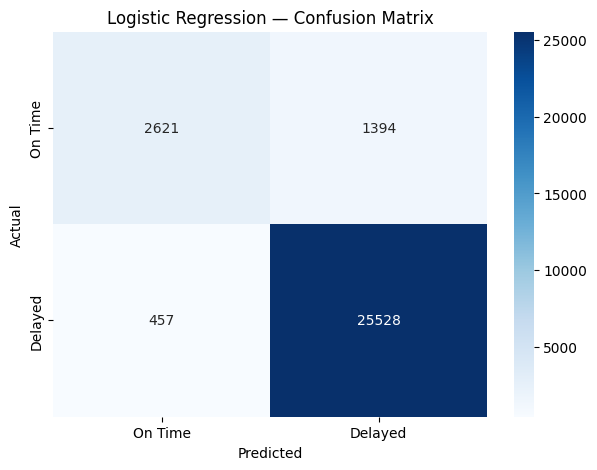

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time", "Delayed"],
    yticklabels=["On Time", "Delayed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [ ]:
# Get feature names after preprocessing
feature_names = logistic_model_scaled.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get model coefficients
coefficients = logistic_model_scaled.named_steps[
    "classifier"
].coef_[0]

# Create a table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

# Top 15 most influential features
top_features = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
).head(15)

print(top_features[["Feature", "Coefficient"]].to_string(index=False))

                          Feature  Coefficient
categorical__Congestion_Band_High     1.778689
    categorical__Route_MAA → VOBL    -1.450324
     categorical__Route_TRZ → COK    -1.336183
     categorical__Route_CCU → BDQ     1.300889
 categorical__Congestion_Band_Low    -1.275667
     categorical__Route_AMD → STV    -1.242520
     categorical__Route_ATQ → COK     1.241568
     categorical__Route_BLR → NAG     1.236450
     categorical__Route_MAA → DIB    -1.172750
     categorical__Route_COK → RPR     1.120602
     categorical__Route_MAA → JLR    -1.110783
     categorical__Route_COK → VNS     1.099172
     categorical__Route_BLR → TIR    -1.084904
     categorical__Route_JAI → AMD     1.060427
    categorical__Route_MAA → VOPN    -1.045579


In [ ]:
from sklearn.inspection import permutation_importance

print("Calculating permutation importance...")

perm_importance = permutation_importance(
    logistic_model_scaled,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 features:")
print(importance_df.head(15).to_string(index=False))

Calculating permutation importance...

Top 15 features:
                      Feature   Importance
      Origin_Congestion_Index 4.476640e-02
              Congestion_Band 2.630974e-02
Previous_Flight_Delay_Minutes 1.202287e-02
         Turnaround_Risk_Band 6.422586e-03
                  Rainfall_mm 8.942062e-04
                      Airline 1.787058e-04
  Scheduled_Departure_Minutes 7.895477e-05
     Scheduled_Departure_Hour 7.442426e-05
                        Month 6.385202e-05
                  Day_of_Week 5.550988e-05
          Departure_Time_Band 4.622202e-05
                Visibility_km 2.684117e-05
   Scheduled_Departure_Minute 1.809646e-05
              Cloud_Cover_pct 1.881853e-06
                Temperature_C 4.824446e-07


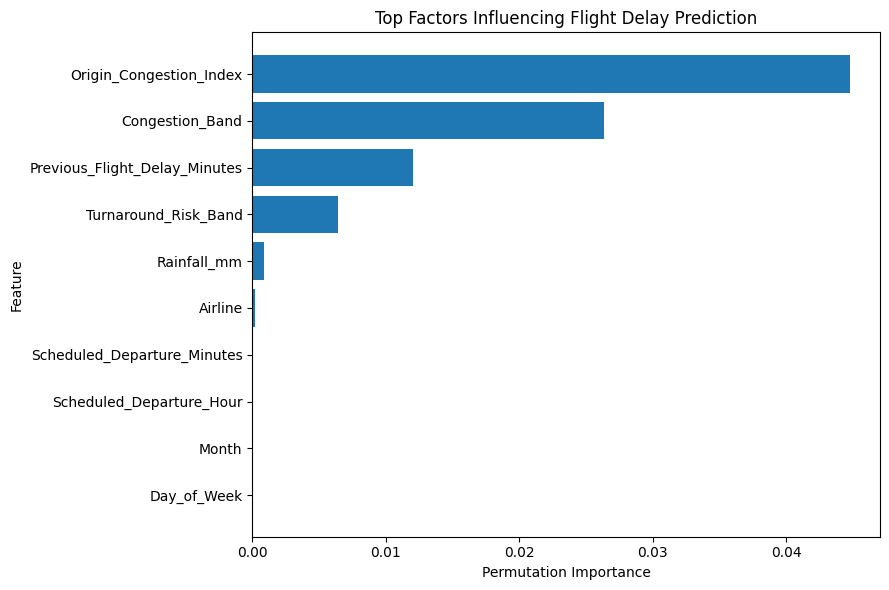

In [ ]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Flight Delay Prediction")

plt.tight_layout()
plt.show()

In [ ]:
# Create delay probability and operational risk categories

prediction_output = X_test.copy()

prediction_output["Actual_Delay"] = y_test.values
prediction_output["Delay_Probability"] = y_prob

prediction_output["Risk_Level"] = pd.cut(
    prediction_output["Delay_Probability"],
    bins=[0, 0.40, 0.70, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

print(prediction_output[[
    "Actual_Delay",
    "Delay_Probability",
    "Risk_Level"
]].head(10))

        Actual_Delay  Delay_Probability   Risk_Level
142561             1           0.940165    High Risk
129644             1           0.946673    High Risk
40807              1           0.950137    High Risk
108992             1           0.978417    High Risk
89146              1           0.991591    High Risk
76136              1           0.977620    High Risk
58696              0           0.540732  Medium Risk
55124              1           0.980201    High Risk
108569             0           0.979720    High Risk
95086              1           0.975827    High Risk


In [ ]:
# Risk-level summary

risk_summary = prediction_output.groupby("Risk_Level", observed=True).agg(
    Flights=("Actual_Delay", "count"),
    Actual_Delays=("Actual_Delay", "sum"),
    Avg_Delay_Probability=("Delay_Probability", "mean")
).reset_index()

risk_summary["Actual_Delay_Rate"] = (
    risk_summary["Actual_Delays"] / risk_summary["Flights"]
)

risk_summary["Avg_Delay_Probability"] = (
    risk_summary["Avg_Delay_Probability"] * 100
).round(2)

risk_summary["Actual_Delay_Rate"] = (
    risk_summary["Actual_Delay_Rate"] * 100
).round(2)

print(risk_summary)

    Risk_Level  Flights  Actual_Delays  Avg_Delay_Probability  \
0     Low Risk     2479            205                  17.66   
1  Medium Risk     1612            995                  55.25   
2    High Risk    25909          24785                  95.29   

   Actual_Delay_Rate  
0               8.27  
1              61.72  
2              95.66  


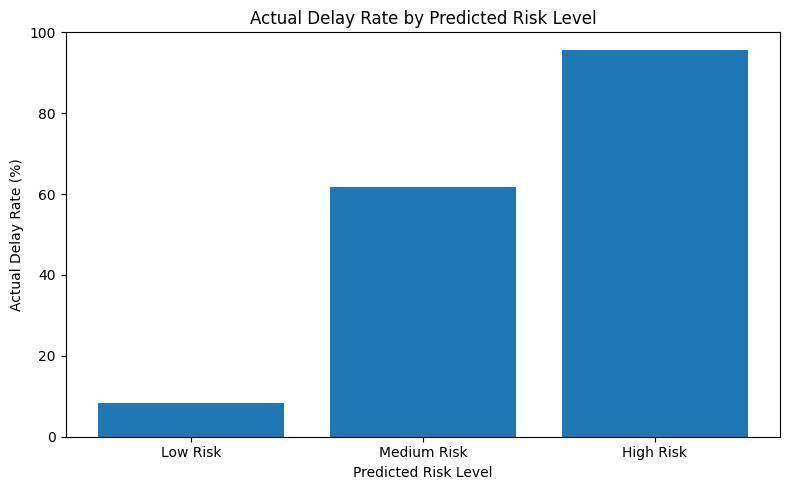

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["Risk_Level"].astype(str),
    risk_summary["Actual_Delay_Rate"]
)

plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Delay Rate (%)")
plt.title("Actual Delay Rate by Predicted Risk Level")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()